<center><h2> Cancer Drug Sensitivity
<center><h4> Dr. Quincy Snell

**Source:** GDSC (Genomics of Drug Sensitivity in Cancer) Database – https://www.kaggle.com/datasets/samiraalipour/genomics-of-drug-sensitivity-in-cancer-gdsc

**Description:** "This dataset is derived from the Genomics of Drug Sensitivity in Cancer (GDSC) project, which aims to identify molecular features of cancers that predict response to anti-cancer drugs. The dataset focuses on Camptothecin and includes drug sensitivity measurements across diverse cancer cell lines, along with molecular and clinical descriptors."

**Variables (n=19):**
- 'COSMIC_ID'
- 'CELL_LINE_NAME'
- 'TCGA_DESC'
- 'DRUG_ID'
- 'DRUG_NAME'
- 'LN_IC50'
- 'AUC'
- 'Z_SCORE'
- 'GDSC_Tissue_descriptor_1'
- 'GDSC_Tissue_descriptor_2'
- 'Cancer_Type_(matching_TCGA_label)'
- 'Microsatellite_instability_Status_(MSI)'
- 'Screen_Medium'
- 'Growth_Properties'
- 'CNA'
- 'Gene_Expression'
- 'Methylation'
- 'TARGET'
- 'TARGET_PATHWAY'

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import scipy.stats as stats
from scipy.stats import skew, norm, probplot, boxcox, f_oneway

import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_excel("/content/Cancer_Drug_Dataset.xlsx")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 967 entries, 0 to 966
Data columns (total 19 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   COSMIC_ID                                967 non-null    int64  
 1   CELL_LINE_NAME                           967 non-null    object 
 2   TCGA_DESC                                961 non-null    object 
 3   DRUG_ID                                  967 non-null    int64  
 4   DRUG_NAME                                967 non-null    object 
 5   LN_IC50                                  967 non-null    float64
 6   AUC                                      967 non-null    float64
 7   Z_SCORE                                  967 non-null    float64
 8   GDSC_Tissue_descriptor_1                 928 non-null    object 
 9   GDSC_Tissue_descriptor_2                 928 non-null    object 
 10  Cancer_Type_(matching_TCGA_label)        763 non-n

In [ ]:
# Fix data types
# df['colname'] = df['colname'].astype('category')
# df['colname'] = df['colname'].astype('float')
# df['colname'] = df['colname'].astype('int')

df['Growth_Properties'] = df['Growth_Properties'].astype('category')

# Create RESISTANT outcome variable based on median LN_IC50
# (0 = Sensitive, 1 = Resistant)
median_ic50 = df['LN_IC50'].median()
df['RESISTANT'] = (df['LN_IC50'] > median_ic50).astype(int)
df['RESISTANT'] = df['RESISTANT'].astype('category')

# Rename long column names for readability
df.rename({'Microsatellite_instability_Status_(MSI)': 'MSI'}, axis=1, inplace=True)
df.rename({'Cancer_Type_(matching_TCGA_label)': 'Cancer_Type'}, axis=1, inplace=True)

In [ ]:
df.RESISTANT

,RESISTANT
0,1
1,0
2,0
3,0
4,0
...,...
962,1
963,1
964,1
965,1


In [ ]:
# Map 0's and 1's to 'Sensitive' and 'Resistant', respectively
df.RESISTANT = df['RESISTANT'].map({0: 'Sensitive', 1: 'Resistant'})

In [ ]:
# After running code above, 0's become 'Sensitive' and 1's become 'Resistant'
df.RESISTANT

,RESISTANT
0,Resistant
1,Sensitive
2,Sensitive
3,Sensitive
4,Sensitive
...,...
962,Resistant
963,Resistant
964,Resistant
965,Resistant


In [ ]:
# To recode categories back into numbers use this code:
df.RESISTANT = df['RESISTANT'].map({'Sensitive': 0, 'Resistant': 1})

In [ ]:
df.RESISTANT

,RESISTANT
0,1
1,0
2,0
3,0
4,0
...,...
962,1
963,1
964,1
965,1


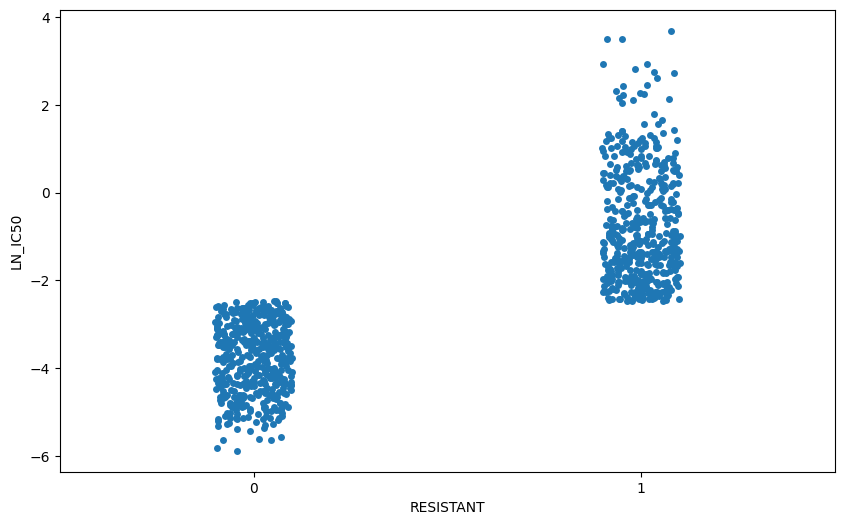

In [ ]:
plt.figure(figsize=(10,6))
sns.stripplot(data=df, x='RESISTANT', y='LN_IC50', jitter=True);

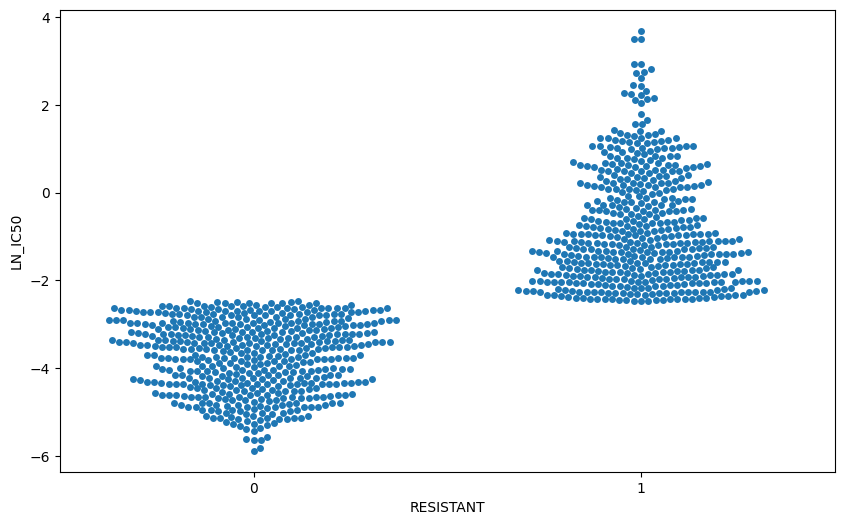

In [ ]:
plt.figure(figsize=(10,6))
sns.swarmplot(data=df, x='RESISTANT', y='LN_IC50');

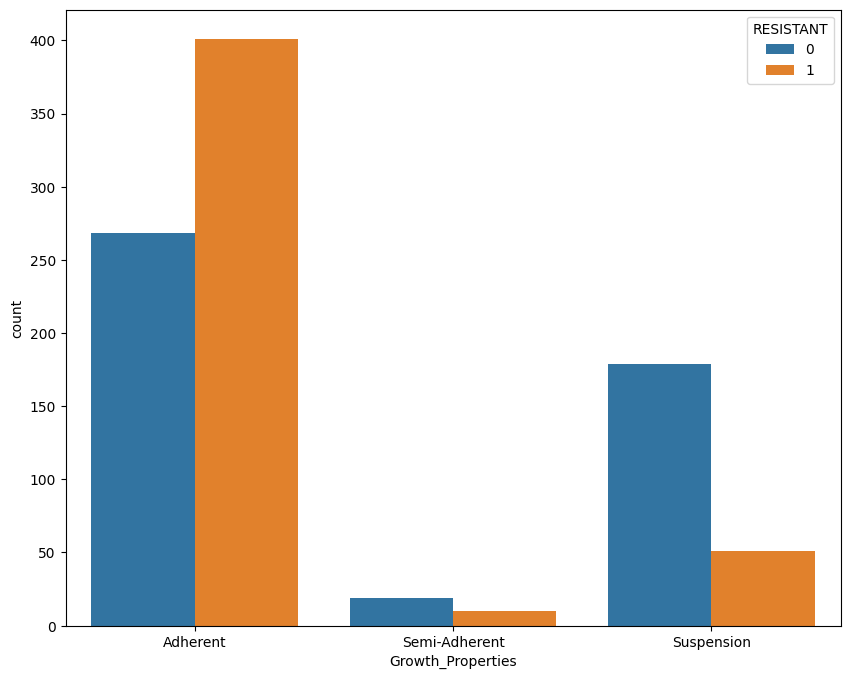

In [ ]:
plt.figure(figsize=(10,8))
sns.countplot(data=df, x='Growth_Properties', hue='RESISTANT');

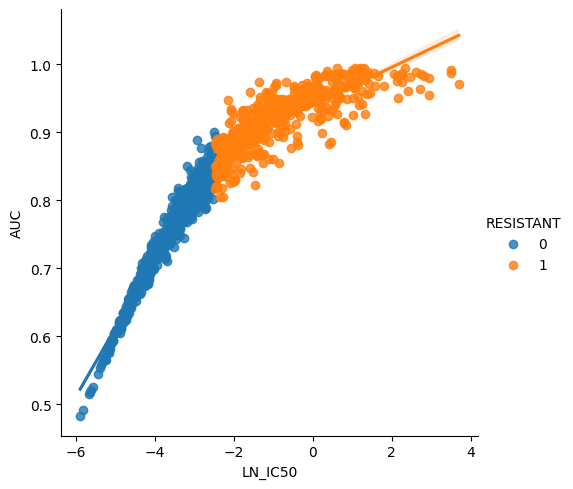

In [ ]:
sns.lmplot(data=df, x='LN_IC50', y='AUC', hue='RESISTANT', fit_reg=True);

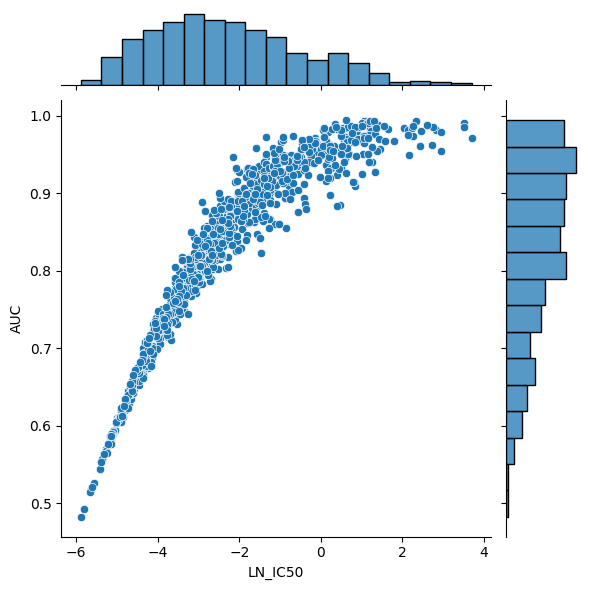

In [ ]:
sns.jointplot(data=df, x='LN_IC50', y='AUC', kind='scatter');

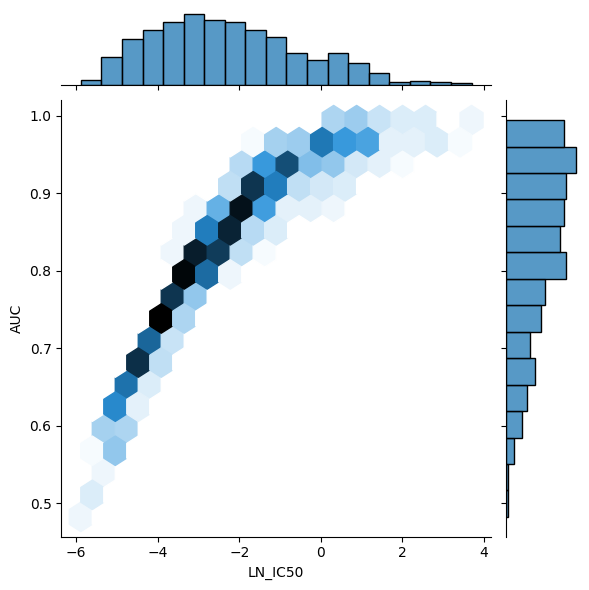

In [ ]:
sns.jointplot(data=df, x='LN_IC50', y='AUC', kind='hex');

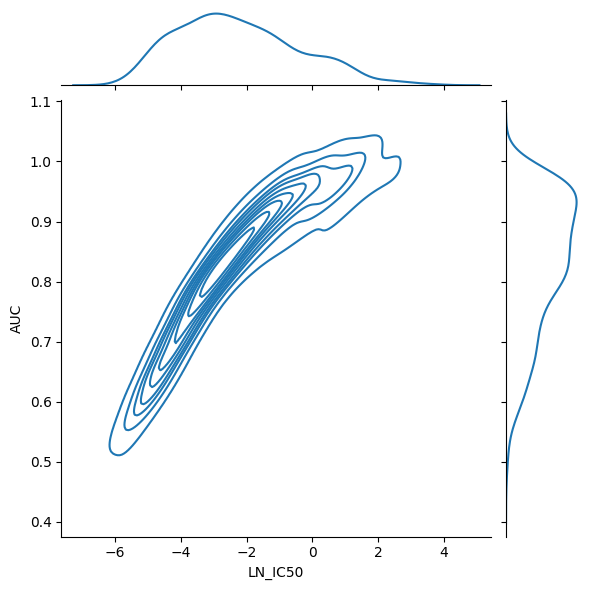

In [ ]:
sns.jointplot(data=df, x='LN_IC50', y='AUC', kind='kde');

# Inferential Statistics

In [ ]:
import numpy as np
import pandas as pd
import math
from scipy import stats
from scipy.stats import   ttest_1samp
import seaborn as sns

### Replace missing data with the median
df_imputed = df.fillna(df.median())

## One Sample t-test

In [ ]:
# one sample t-test
## Null hypothesis?
t_statistic, p_value = ttest_1samp(df.AUC, 0.88)
print('One sample t test \nt statistic = {0}, p value = {1} '.format(t_statistic, p_value))

One sample t test 
t statistic = -14.259700194060363, p value = 5.197640790800129e-42 


#### Reject or fail to reject the null hypothesis?

In [ ]:
df.AUC.mean()

np.float64(0.8284607104446743)

## Independent t-test

In [ ]:
from scipy.stats import ttest_ind
ttest_ind(df.AUC[df.RESISTANT == 0], df.AUC[df.RESISTANT == 1])

TtestResult(statistic=np.float64(-41.862572692828444), pvalue=np.float64(3.5819674116975046e-219), df=np.float64(965.0))

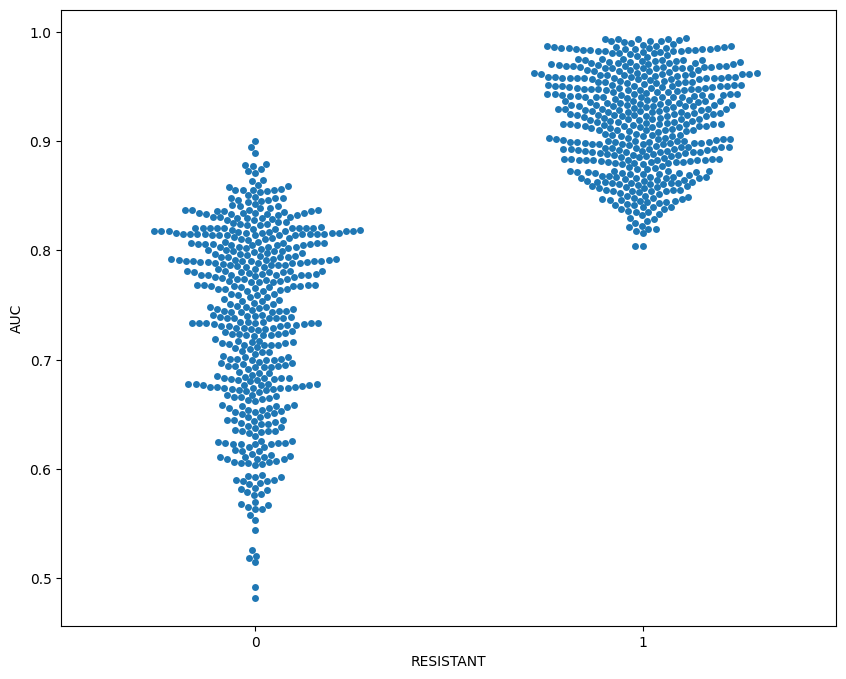

In [ ]:
plt.figure(figsize=(10,8))
sns.swarmplot(data=df, x='RESISTANT', y='AUC');

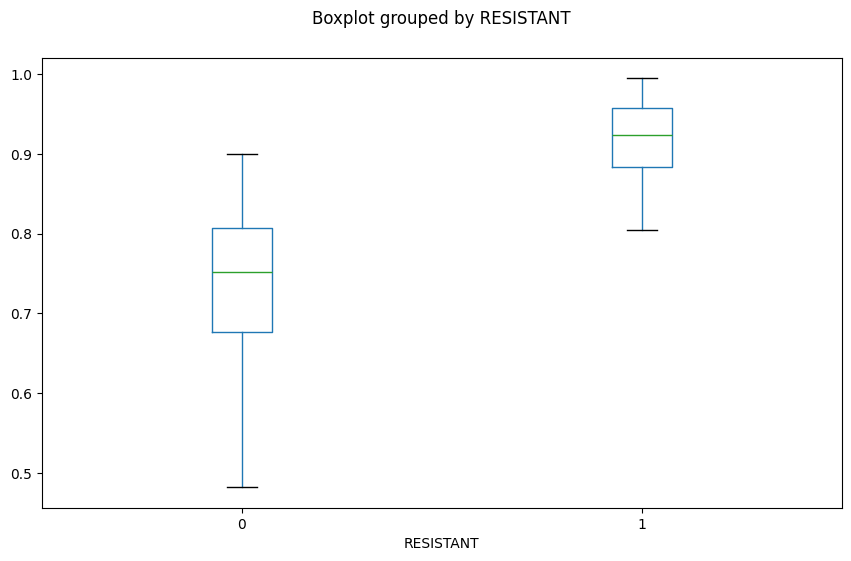

In [ ]:
ttest_boxplot = df.boxplot(column='AUC', by='RESISTANT', figsize=(10, 6), grid=False);
ttest_boxplot.set_title('');
ttest_boxplot.set_ylabel('');

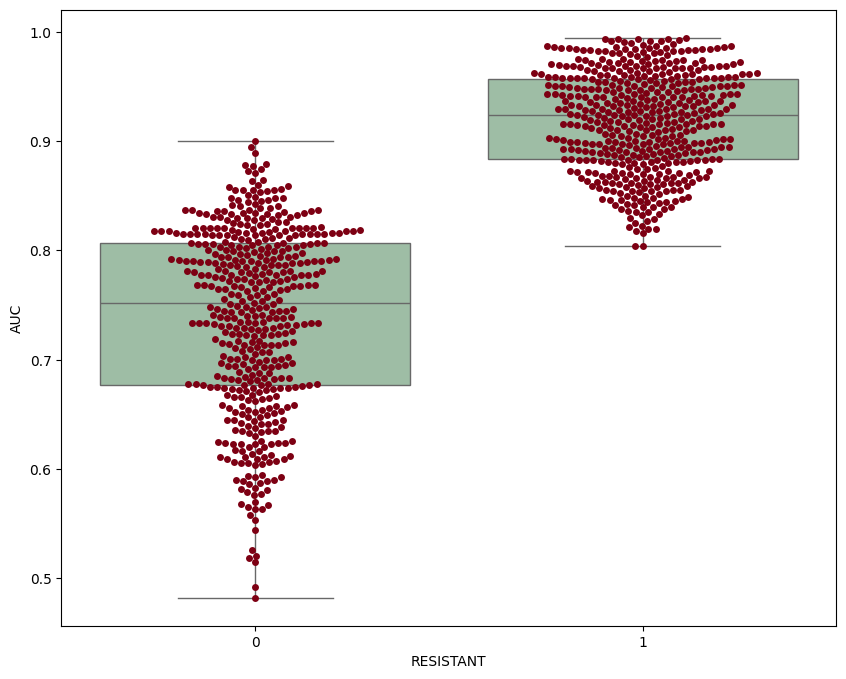

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,8))
ax = sns.boxplot(x='RESISTANT', y='AUC', data=df, color='#99c2a2')
ax = sns.swarmplot(x='RESISTANT', y='AUC', data=df, color='#7d0013')
plt.show()

In [ ]:
df.RESISTANT

,RESISTANT
0,1
1,0
2,0
3,0
4,0
...,...
962,1
963,1
964,1
965,1


## Mann-Whitney-U Test

In [ ]:
# Separate Sensitive and Resistant cell lines into two groups
group0 = df[df['RESISTANT'] == 0]
group1 = df[df['RESISTANT'] == 1]

In [ ]:
group0.info()
print("")
group1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 484 entries, 1 to 960
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   COSMIC_ID                 484 non-null    int64   
 1   CELL_LINE_NAME            484 non-null    object  
 2   TCGA_DESC                 482 non-null    object  
 3   DRUG_ID                   484 non-null    int64   
 4   DRUG_NAME                 484 non-null    object  
 5   LN_IC50                   484 non-null    float64 
 6   AUC                       484 non-null    float64 
 7   Z_SCORE                   484 non-null    float64 
 8   GDSC_Tissue_descriptor_1  466 non-null    object  
 9   GDSC_Tissue_descriptor_2  466 non-null    object  
 10  Cancer_Type               361 non-null    object  
 11  MSI                       461 non-null    object  
 12  Screen_Medium             466 non-null    object  
 13  Growth_Properties         466 non-null    category
 14 

In [ ]:
group0

,COSMIC_ID,CELL_LINE_NAME,TCGA_DESC,DRUG_ID,DRUG_NAME,LN_IC50,AUC,Z_SCORE,GDSC_Tissue_descriptor_1,GDSC_Tissue_descriptor_2,Cancer_Type,MSI,Screen_Medium,Growth_Properties,CNA,Gene_Expression,Methylation,TARGET,TARGET_PATHWAY,RESISTANT
1,684057,ES5,UNCLASSIFIED,1003,Camptothecin,-3.360586,0.791072,-0.599569,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication,0
2,684059,ES7,UNCLASSIFIED,1003,Camptothecin,-5.044940,0.592660,-1.516647,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication,0
3,684062,EW-11,UNCLASSIFIED,1003,Camptothecin,-3.741991,0.734047,-0.807232,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication,0
4,684072,SK-ES-1,UNCLASSIFIED,1003,Camptothecin,-5.142961,0.582439,-1.570016,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Semi-Adherent,Y,Y,Y,TOP1,DNA replication,0
6,687452,5637,BLCA,1003,Camptothecin,-2.632632,0.834067,-0.203221,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TOP1,DNA replication,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
953,1524417,RCC-ER,KIRC,1003,Camptothecin,-3.572036,0.760573,-0.714697,kidney,kidney,KIRC,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication,0
954,1524418,RCC-AB,KIRC,1003,Camptothecin,-3.075722,0.775804,-0.444470,kidney,kidney,KIRC,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication,0
957,1659818,MM1S,MM,1003,Camptothecin,-3.797156,0.768343,-0.837267,myeloma,myeloma,MM,MSS/MSI-L,R,Suspension,Y,Y,Y,TOP1,DNA replication,0
958,1659819,OCI-LY7,DLBC,1003,Camptothecin,-4.664312,0.654447,-1.309407,lymphoma,B_cell_lymphoma,DLBC,NaN,D/F12,Suspension,Y,Y,N,TOP1,DNA replication,0


In [ ]:
group1

,COSMIC_ID,CELL_LINE_NAME,TCGA_DESC,DRUG_ID,DRUG_NAME,LN_IC50,AUC,Z_SCORE,GDSC_Tissue_descriptor_1,GDSC_Tissue_descriptor_2,Cancer_Type,MSI,Screen_Medium,Growth_Properties,CNA,Gene_Expression,Methylation,TARGET,TARGET_PATHWAY,RESISTANT
0,683667,PFSK-1,MB,1003,Camptothecin,-1.463887,0.930220,0.433123,nervous_system,medulloblastoma,MB,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication,1
5,687448,COLO-829,SKCM,1003,Camptothecin,-1.235034,0.867348,0.557727,skin,melanoma,SKCM,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication,1
8,687457,SW780,BLCA,1003,Camptothecin,-1.449138,0.905050,0.441154,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication,1
9,687459,TCCSUP,BLCA,1003,Camptothecin,-2.350633,0.843430,-0.049682,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication,1
11,687506,C-4-I,CESC,1003,Camptothecin,-2.255690,0.891103,0.002012,urogenital_system,cervix,CESC,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
962,1660034,SNU-407,COREAD,1003,Camptothecin,-1.612538,0.898987,0.352188,large_intestine,large_intestine,COAD/READ,MSI-H,R,Adherent,Y,Y,Y,TOP1,DNA replication,1
963,1660035,SNU-61,COREAD,1003,Camptothecin,1.343563,0.984610,1.961691,large_intestine,large_intestine,COAD/READ,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication,1
964,1660036,SNU-81,COREAD,1003,Camptothecin,0.073547,0.984230,1.270207,large_intestine,large_intestine,COAD/READ,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication,1
965,1674021,SNU-C5,COREAD,1003,Camptothecin,-2.421554,0.835886,-0.088296,large_intestine,large_intestine,COAD/READ,MSI-H,R,Adherent,Y,Y,Y,TOP1,DNA replication,1


In [ ]:
from scipy.stats import mannwhitneyu
stats.mannwhitneyu(group0.AUC, group1.AUC)

MannwhitneyuResult(statistic=np.float64(2694.0), pvalue=np.float64(2.1280765461242223e-152))

## ANOVA

In [ ]:
# Use this code to get ANOVA table
import statsmodels.api as sm
from statsmodels.formula.api import ols
model = ols('AUC ~ RESISTANT', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2) # type II sum of squares method used in ANOVA calculations
anova_table

,sum_sq,df,F,PR(>F)
RESISTANT,7.869478,1.0,1752.474992,3.581967e-219
Residual,4.333327,965.0,NaN,NaN


- Table above shows AUC differences between Sensitive and Resistant cell lines

## Kruskal Wallis

In [ ]:
stats.kruskal(df['AUC'], df['RESISTANT'])

KruskalResult(statistic=np.float64(0.0016004000623996452), pvalue=np.float64(0.9680891396895326))

## Chi-Square

In [ ]:
from scipy.stats import chisquare

In [ ]:
# Example 1
crosstab = pd.crosstab(df['RESISTANT'], df['Screen_Medium'] == 'R') # Where Screen_Medium == 'R' is True
crosstab

Screen_Medium,False,True
RESISTANT,,
0,218,266
1,235,248


In [ ]:
stats.chi2_contingency(crosstab)

Chi2ContingencyResult(statistic=np.float64(1.1263453005113824), pvalue=np.float64(0.28855623756154425), dof=1, expected_freq=array([[226.73422958, 257.26577042],
       [226.26577042, 256.73422958]]))

- First value is the chi-square value
- Second value is the p-value
- Third value is degrees of freedom
- The array contains expected frequencies; we desire all expected frequencies to be > 5

In [ ]:
# Example 2
crosstab = pd.crosstab(df['RESISTANT'], df['Growth_Properties'])
crosstab

Growth_Properties,Adherent,Semi-Adherent,Suspension
RESISTANT,,,
0,268,19,179
1,401,10,51


In [ ]:
stats.chi2_contingency(crosstab)

Chi2ContingencyResult(statistic=np.float64(100.45346766164197), pvalue=np.float64(1.5374700103548188e-22), dof=2, expected_freq=array([[335.94181034,  14.5625    , 115.49568966],
       [333.05818966,  14.4375    , 114.50431034]]))

In [ ]:
print(f"Sensitive mean LN_IC50: {df.LN_IC50[df.RESISTANT == 0].mean():.4f}")
print(f"Resistant mean LN_IC50: {df.LN_IC50[df.RESISTANT == 1].mean():.4f}")

Sensitive mean LN_IC50: -3.7401
Resistant mean LN_IC50: -0.7702


In [ ]:
print(f"Sensitive AUC mean: {df.AUC[df.RESISTANT == 0].mean():.4f}")
print(f"Resistant AUC mean: {df.AUC[df.RESISTANT == 1].mean():.4f}")

Sensitive AUC mean: 0.7383
Resistant AUC mean: 0.9188


In [ ]:
!jupyter nbconvert --to html /content/*.ipynb

[NbConvertApp] Converting notebook /content/Cancer_Drug_Inferential_Statistics (5).ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 10 image(s).
[NbConvertApp] Writing 866337 bytes to /content/Cancer_Drug_Inferential_Statistics (5).html
